In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler



In [9]:
# 1. Custom Dataset ─────────────────────────────
class IrisDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
#2. Load & prepare data ────────────────────────
iris    = load_iris()
X, y    = iris.data, iris.target

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

dataset  = IrisDataset(X_scaled, y)

# Split: 70% train, 15% val, 15% test
n        = len(dataset)
n_train  = int(0.7 * n)
n_val    = int(0.15 * n)
n_test   = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42))

 




In [11]:
#3. DataLoaders ────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Samples/epoch : {len(train_ds)}")

# Inspect one batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape : {X_batch.shape}")
print(f"Batch y shape : {y_batch.shape}")


Train batches : 7
Val batches   : 2
Samples/epoch : 105
Batch X shape : torch.Size([16, 4])
Batch y shape : torch.Size([16])


In [12]:
#4. Model ──────────────────────────────────────
class IrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(16, 3)
        )
    def forward(self, x):
        return self.net(x)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = IrisNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Learning rate scheduler — halve LR every 30 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

In [13]:
#5. Full training loop with batches ────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        preds = model(X_b)
        loss  = criterion(preds, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_b)
        correct    += (preds.argmax(1) == y_b).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            preds     = model(X_b)
            loss      = criterion(preds, y_b)
            total_loss += loss.item() * len(X_b)
            correct    += (preds.argmax(1) == y_b).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [14]:
# 6. Train with checkpointing ───────────────────
history    = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_loss = float('inf')
EPOCHS     = 100

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    # Save best model
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), 'best_model.pth')

    if epoch % 20 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d} | LR: {lr:.5f} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
              f"Val Loss: {va_loss:.4f} Acc: {va_acc:.4f}")

Epoch   0 | LR: 0.01000 | Train Loss: 1.0279 Acc: 0.4857 | Val Loss: 0.9522 Acc: 0.5000
Epoch  20 | LR: 0.01000 | Train Loss: 0.0812 Acc: 0.9810 | Val Loss: 0.0519 Acc: 0.9545
Epoch  40 | LR: 0.00500 | Train Loss: 0.0370 Acc: 1.0000 | Val Loss: 0.1277 Acc: 0.9545
Epoch  60 | LR: 0.00250 | Train Loss: 0.0810 Acc: 0.9905 | Val Loss: 0.2478 Acc: 0.9545
Epoch  80 | LR: 0.00250 | Train Loss: 0.0282 Acc: 0.9810 | Val Loss: 0.2198 Acc: 0.9545


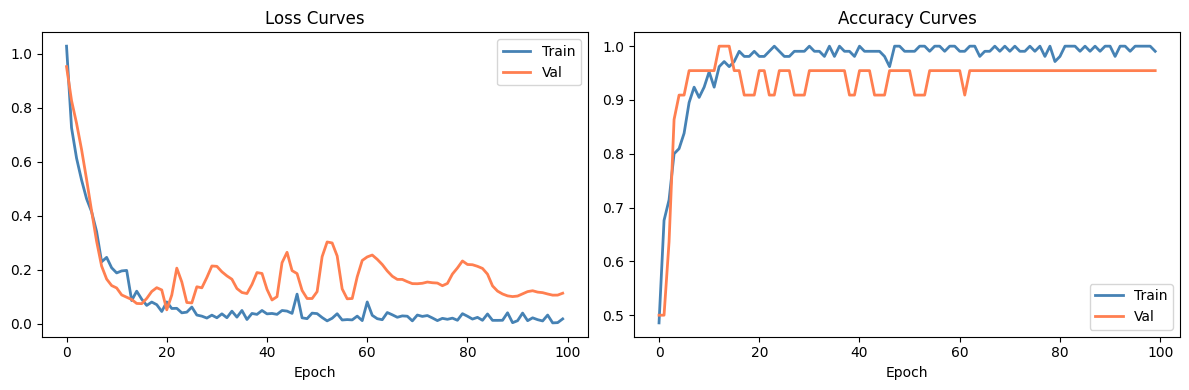

In [15]:
#7. Plot training curves ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(history['val_loss'],   label='Val',   color='coral',     lw=2)
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train', color='steelblue', lw=2)
axes[1].plot(history['val_acc'],   label='Val',   color='coral',     lw=2)
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()


In [16]:
#8. Load best model & test ─────────────────────
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"\nBest model — Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")


Best model — Test Loss: 0.2606 | Test Acc: 0.8696
Current LR: 0.001250
